In [33]:
# set brainpy
# please "pip install brainpy" , my version is 2.4.4
import brainpy as bp
import brainpy.math as bm
import brainpy_datasets as bd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore
import pandas as pd
import scipy.sparse as sp
import os
from tqdm import tqdm
import seaborn as sns

bm.enable_x64()
bm.set_platform('cpu')
# test version
bp.__version__

'2.4.4'

In [34]:
# 设置工作目录
#os.chdir('lorenz')

# 1. 加载数据并确保名称一致性
# 连接概率矩阵
conn_df = pd.read_csv('TIN_conn.csv', index_col=0)
# 神经元数量
number_df = pd.read_csv('TIN_number.csv', header=None, names=['population', 'count'])
number_df = number_df.round(0)
# 连接权重矩阵
weight_df = pd.read_csv('TIN_weight.csv', index_col=0)

# 确保所有数据框使用相同的群体名称顺序
# 使用连接矩阵的行列名称作为基准
populations = conn_df.index.tolist()

# 重新索引权重矩阵以匹配连接矩阵的顺序
weight_df = weight_df.loc[populations, populations]

# 创建神经元数量字典（按名称索引）
pop_counts = {row['population']: row['count'] for _, row in number_df.iterrows()}

# 2. 创建神经元映射表
neuron_map = {}
current_index = 0
neuron_list = []

for pop in populations:
    count = int(pop_counts[pop])
    for i in range(count):
        neuron_id = f"{pop}_{i}"
        neuron_map[neuron_id] = current_index
        neuron_list.append(neuron_id)
        current_index += 1

total_neurons = current_index

# 3. 初始化稀疏矩阵
matrix = sp.lil_matrix((total_neurons, total_neurons), dtype=np.float32)

# 4. 处理每个群体对（基于名称索引）
for i, pop_i in tqdm(enumerate(populations), total=len(populations), desc="处理群体对"):
    # 获取源群体信息
    count_i = int(pop_counts[pop_i])
    start_i = neuron_map[f"{pop_i}_0"]  # 获取起始索引
    
    for j, pop_j in enumerate(populations):
        # 获取目标群体信息
        count_j = int(pop_counts[pop_j])
        start_j = neuron_map[f"{pop_j}_0"]  # 获取起始索引
        
        # 获取连接概率和基础权重（按名称索引）
        prob = conn_df.loc[pop_i, pop_j]
        base_weight = weight_df.loc[pop_i, pop_j]
        
        # 抑制性神经元处理
        weight = -base_weight if pop_i.startswith('I') else base_weight
        
        # 跳过无效连接
        if prob == 0 or weight == 0:
            continue
        
        # 生成随机连接
        random_matrix = np.random.rand(count_i, count_j) < prob
        rows, cols = np.where(random_matrix)
        
        # 转换为全局索引
        global_rows = rows + start_i
        global_cols = cols + start_j
        
        # 添加到稀疏矩阵
        matrix[global_rows, global_cols] = weight

# 转换为CSR格式
csr_matrix = matrix.tocsr()

# 5. 保存为NPZ格式（稀疏矩阵）
print("\n保存为NPZ格式...")
sp.save_npz('single_neuron_weights.npz', csr_matrix)
print("连接矩阵已保存为 single_neuron_weights.npz")

# 6. 导出为稀疏CSV格式（仅非零元素）
print("\n开始导出连接矩阵为CSV...")
non_zero_rows, non_zero_cols = csr_matrix.nonzero()
non_zero_data = csr_matrix.data

# 创建结果DataFrame
result_df = pd.DataFrame({
    'source': [neuron_list[row] for row in non_zero_rows],
    'target': [neuron_list[col] for col in non_zero_cols],
    'weight': non_zero_data
})

# 保存为CSV
result_df.to_csv('single_neuron_connections.csv', index=False)
print(f"连接矩阵已保存为 single_neuron_connections.csv，包含 {len(result_df)} 条连接")

# 7. 保存神经元映射表
neuron_df = pd.DataFrame({
    'neuron_id': neuron_list,
    'population': [n.split('_')[0] for n in neuron_list],
    'index': range(total_neurons)
})
neuron_df.to_csv('neuron_mapping.csv', index=False)
print("神经元映射表已保存为 neuron_mapping.csv")

# 输出统计信息
print("\n处理完成！")
print(f"总神经元数量: {total_neurons}")
print(f"非零连接数量: {csr_matrix.nnz}")
print(f"稀疏度: {csr_matrix.nnz / (total_neurons**2):.6f}")

处理群体对: 100%|█████████████████████████████████████████████████████████████████████| 44/44 [00:00<00:00, 690.85it/s]


保存为NPZ格式...
连接矩阵已保存为 single_neuron_weights.npz

开始导出连接矩阵为CSV...
连接矩阵已保存为 single_neuron_connections.csv，包含 6610 条连接
神经元映射表已保存为 neuron_mapping.csv

处理完成！
总神经元数量: 1148
非零连接数量: 6610
稀疏度: 0.005016


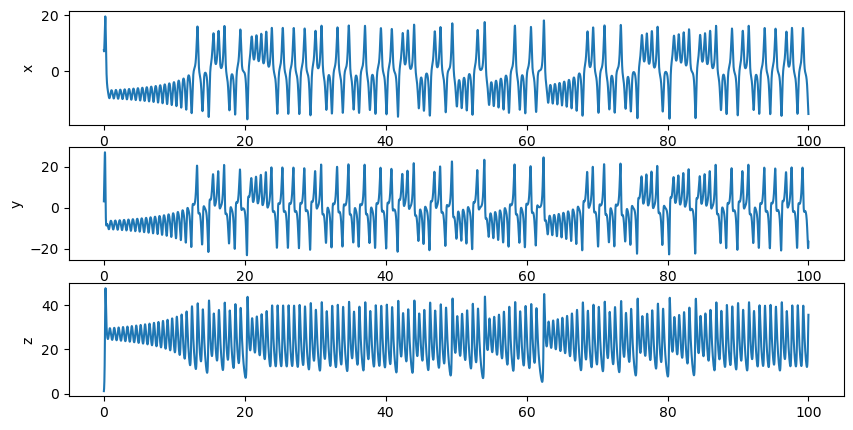

In [35]:
## 引入三维的洛伦兹序列
dt = 0.01
data = bd.chaos.LorenzEq(100, dt=dt)

plt.figure(figsize=(10, 5))
plt.subplot(311)
plt.plot(bm.as_numpy(data.ts), bm.as_numpy(data.xs.flatten()))
plt.ylabel('x')
plt.subplot(312)
plt.plot(bm.as_numpy(data.ts), bm.as_numpy(data.ys.flatten()))
plt.ylabel('y')
plt.subplot(313)
plt.plot(bm.as_numpy(data.ts), bm.as_numpy(data.zs.flatten()))
plt.ylabel('z')
plt.show()

In [6]:
import numpy as np
import scipy.sparse as sp
import pandas as pd
from scipy.sparse.linalg import eigs
import os
import time

# 设置工作目录
#os.chdir('lorenz')

# 1. 加载之前生成的神经元连接矩阵
print("加载神经元连接矩阵...")
start_time = time.time()
csr_matrix = sp.load_npz('single_neuron_weights.npz')
print(f"矩阵加载完成，耗时: {time.time()-start_time:.2f}秒")
print(f"原始矩阵形状: {csr_matrix.shape}")
print(f"原始非零元素数量: {csr_matrix.nnz}")

# 2. 计算谱半径 (最大特征值的模)
print("\n计算谱半径...")
start_time = time.time()

# 使用幂迭代法近似最大特征值
def power_iteration(A, num_iterations=10):
    n = A.shape[0]
    v = np.random.rand(n)
    for _ in range(num_iterations):
        Av = A @ v
        v = Av / np.linalg.norm(Av)
    return v.T @ (A @ v)  # 瑞利商

# 计算谱半径
max_eigenvalue = power_iteration(csr_matrix)
spectral_radius = np.abs(max_eigenvalue)
print(f"原始谱半径: {spectral_radius:.6f}")
print(f"计算耗时: {time.time()-start_time:.2f}秒")

# 3. 缩放矩阵使谱半径约为1
print("\n缩放矩阵使谱半径≈1...")
scaling_factor = 1.0 / spectral_radius
scaled_matrix = csr_matrix * scaling_factor

# 验证缩放后谱半径
scaled_spectral_radius = np.abs(power_iteration(scaled_matrix))
print(f"缩放后谱半径: {scaled_spectral_radius:.6f}")



# 5. 转换为密集NumPy数组
print("\n转换为密集NumPy数组...")
start_time = time.time()
dense_matrix = scaled_matrix.toarray()

print(f"转换完成，耗时: {time.time()-start_time:.2f}秒")
print(f"密集矩阵形状: {dense_matrix.shape}")
print(f"内存占用: {dense_matrix.nbytes / (1024**2):.2f} MB")

# 6. 保存为NumPy二进制文件sha
print("\n保存为NumPy格式...")
np.save('compressed_weight_matrix.npy', dense_matrix)
print("矩阵已保存为 compressed_weight_matrix.npy")



# 8. 加载神经元映射表并创建压缩神经元列表
print("\n处理神经元映射信息...")
neuron_df = pd.read_csv('neuron_mapping.csv')


# 输出统计信息
print("\n处理完成！")
print(f"谱半径: {scaled_spectral_radius:.6f}")

加载神经元连接矩阵...
矩阵加载完成，耗时: 0.02秒
原始矩阵形状: (1148, 1148)
原始非零元素数量: 6682

计算谱半径...
原始谱半径: 83035.500268
计算耗时: 0.00秒

缩放矩阵使谱半径≈1...
缩放后谱半径: 1.000579

转换为密集NumPy数组...
转换完成，耗时: 0.00秒
密集矩阵形状: (1148, 1148)
内存占用: 5.03 MB

保存为NumPy格式...
矩阵已保存为 compressed_weight_matrix.npy

处理神经元映射信息...

处理完成！
谱半径: 1.000579


In [7]:
# 使用pandas的DataFrame来保存矩阵
df = pd.DataFrame(dense_matrix)
 
# 保存为CSV文件
df.to_csv('dense_matrix.csv', index=False)  # index=False表示不保存行索引到CSV文件

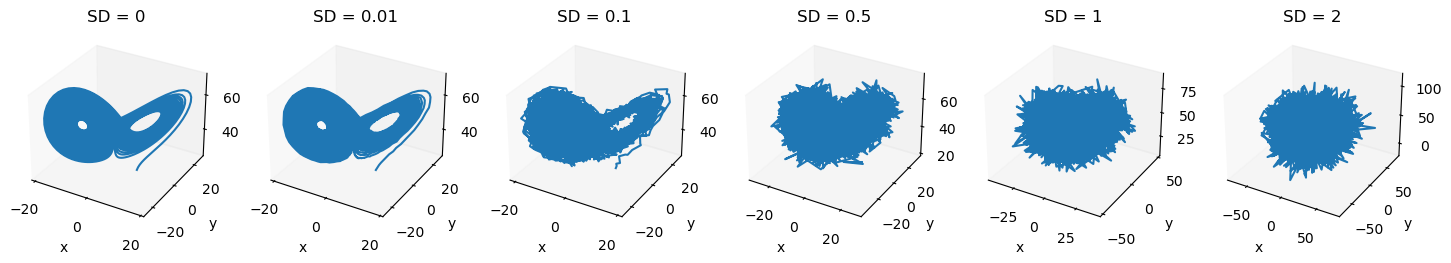

In [8]:
# 构建不同噪音的洛伦兹数据集
def addnoise(data, sd=1):
    data = bd.chaos.LorenzEq(100, dt=dt)
    noise_x = bm.random.normal(np.mean(data.xs), np.std(data.xs)*sd, data.xs.shape)
    data.xs = data.xs+noise_x
    noise_y = bm.random.normal(np.mean(data.ys), np.std(data.ys)*sd, data.ys.shape)
    data.ys = data.ys+noise_y
    noise_z = bm.random.normal(np.mean(data.zs), np.std(data.zs)*sd, data.zs.shape)
    data.zs = data.zs+noise_z
    return data

data0 = addnoise(data,sd=0)
data1 = addnoise(data,sd=0.01)
data2 = addnoise(data,sd=0.1)
data3 = addnoise(data,sd=0.5)
data4 = addnoise(data,sd=1)
data5 = addnoise(data,sd=2)

fig = plt.figure(figsize=(18, 6))
ax = fig.add_subplot(161, projection='3d')
ax.set_title("SD = 0")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.grid(False)
ax.plot(bm.as_numpy(data0.xs).squeeze(),bm.as_numpy(data0.ys).squeeze(), bm.as_numpy(data0.zs).squeeze())

ax1 = fig.add_subplot(162, projection='3d')
ax1.set_title("SD = 0.01")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")
ax1.grid(False)
ax1.plot(bm.as_numpy(data1.xs).squeeze(),bm.as_numpy(data1.ys).squeeze(), bm.as_numpy(data1.zs).squeeze())

ax2 = fig.add_subplot(163, projection='3d')
ax2.set_title("SD = 0.1")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("z")
ax2.grid(False)
ax2.plot(bm.as_numpy(data2.xs).squeeze(),bm.as_numpy(data2.ys).squeeze(), bm.as_numpy(data2.zs).squeeze())

ax3 = fig.add_subplot(164, projection='3d')
ax3.set_title("SD = 0.5")
ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.set_zlabel("z")
ax3.grid(False)
ax3.plot(bm.as_numpy(data3.xs).squeeze(),bm.as_numpy(data3.ys).squeeze(), bm.as_numpy(data3.zs).squeeze())

ax4 = fig.add_subplot(165, projection='3d')
ax4.set_title("SD = 1")
ax4.set_xlabel("x")
ax4.set_ylabel("y")
ax4.set_zlabel("z")
ax4.grid(False)
ax4.plot(bm.as_numpy(data4.xs).squeeze(),bm.as_numpy(data4.ys).squeeze(), bm.as_numpy(data4.zs).squeeze())

ax5 = fig.add_subplot(166, projection='3d')
ax5.set_title("SD = 2")
ax5.set_xlabel("x")
ax5.set_ylabel("y")
ax5.set_zlabel("z")
ax5.grid(False)
ax5.plot(bm.as_numpy(data5.xs).squeeze(),bm.as_numpy(data5.ys).squeeze(), bm.as_numpy(data5.zs).squeeze())

# plt.figure(figsize=(10, 5))
# plt.subplot(311)
# plt.plot(bm.as_numpy(data1.ts), bm.as_numpy(data1.xs.flatten()))
# plt.ylabel('x')
# plt.subplot(312)
# plt.plot(bm.as_numpy(data1.ts), bm.as_numpy(data1.ys.flatten()))
# plt.ylabel('y')
# plt.subplot(313)
# plt.plot(bm.as_numpy(data1.ts), bm.as_numpy(data1.zs.flatten()))
# plt.ylabel('z')
# plt.show()

In [9]:
#  set basal ESN
class ESN(bp.DynamicalSystemNS):
  def __init__(self, num_in, num_hidden, num_out, leaky_rate=0.2, Win_initializer=bp.init.Uniform(-0.1, 0.1), 
               Wrec_initializer=bp.init.Normal(scale=0.1), in_connectivity=1.0, rec_connectivity=1.0, spectral_radius=None, alpha=1.0):
    
    super(ESN, self).__init__()
    self.r = bp.dnn.Reservoir(
        num_in, num_hidden,
        Win_initializer = Win_initializer,
        Wrec_initializer = Wrec_initializer*alpha,   ## biological connectome
        in_connectivity = in_connectivity,
        rec_connectivity = rec_connectivity,               
        spectral_radius = None,
        leaky_rate = leaky_rate,
    )
    self.o = bp.layers.Dense(num_hidden, num_out,W_initializer=bp.init.Normal(), mode=bm.training_mode)

  def update(self, x):
    return x >> self.r >> self.o

In [10]:
TIN_matrix = bm.array(dense_matrix)


def process_matrix(matrix, keep_positive=True, replace_value=0):
    """
    处理矩阵，保留正数或负数
    
    Parameters:
    matrix: 输入矩阵
    keep_positive: True保留非负数，False保留非正数
    replace_value: 替换值，默认为0
    """
    if keep_positive:
        return np.where(matrix >= 0, matrix, replace_value)
    else:
        return np.where(matrix <= 0, matrix, replace_value)

E_TIN = bm.array(process_matrix(dense_matrix, keep_positive=True))
I_TIN = bm.array(process_matrix(dense_matrix, keep_positive=False))


# def shuffle_matrix(matrix):
#     shape = matrix.shape
#     flattened = matrix.flatten()
#     bm.random.shuffle(flattened)
#     return flattened.reshape(shape)

# TIN_shuffle = shuffle_matrix(TIN_matrix)

In [11]:
max_eigenvalue = power_iteration(I_TIN)
spectral_radius = np.abs(max_eigenvalue)
scaling_factor = 1.0 / spectral_radius
scaled_I_TIN = I_TIN * scaling_factor

max_eigenvalue = power_iteration(E_TIN)
spectral_radius = np.abs(max_eigenvalue)
scaling_factor = 1.0 / spectral_radius
scaled_E_TIN = E_TIN * scaling_factor


In [26]:
## training method
def get_subset(data, start, end):
  res = {'x': data.xs[start: end],
         'y': data.ys[start: end],
         'z': data.zs[start: end]}
  res = bm.hstack([res['x'], res['y'], res['z']])
  # Training data must have batch size, here the batch is 1
  return res.reshape((1, ) + res.shape)

dt = 0.01
t_warmup, t_train, t_test = 15, 100., 50.  # ms
num_warmup, num_train, num_test = int(t_warmup/dt), int(t_train/dt), int(t_test/dt)


lorenz_series = bd.chaos.LorenzEq(t_warmup + t_train + t_test,
                                  dt=dt,
                                  inits={'x': 17.67715816276679,
                                         'y': 12.931379185960404,
                                         'z': 43.91404334248268})


def addnoise(data, sd=0.00):
    lorenz_series = bd.chaos.LorenzEq(t_warmup + t_train + t_test,
                                      dt=dt,
                                      inits={'x': 17.67715816276679,
                                             'y': 12.931379185960404,
                                             'z': 43.91404334248268})
    data = lorenz_series
    noise_x = bm.random.normal(np.mean(data.xs), np.std(data.xs)*sd, data.xs.shape)
    data.xs = data.xs+noise_x
    noise_y = bm.random.normal(np.mean(data.ys), np.std(data.ys)*sd, data.ys.shape)
    data.ys = data.ys+noise_y
    noise_z = bm.random.normal(np.mean(data.zs), np.std(data.zs)*sd, data.zs.shape)
    data.zs = data.zs+noise_z
    return data

# 于此处调节噪声
lorenz_series_noise = addnoise(lorenz_series,sd=0.00)
lorenz_series_clean = addnoise(lorenz_series,sd=0)

# 于此处调节步长
step = 1
X_warmup = get_subset(lorenz_series_clean, 0, num_warmup - step)
X_train = get_subset(lorenz_series_clean, num_warmup - step, num_warmup + num_train - step)
X_test = get_subset(lorenz_series_noise,
                    num_warmup + num_train - step,
                    num_warmup + num_train + num_test - step)


# out target data is the activity ahead of 5 time steps
Y_train = get_subset(lorenz_series_clean, num_warmup, num_warmup + num_train)
Y_test = get_subset(lorenz_series_noise,
                    num_warmup + num_train,
                    num_warmup + num_train + num_test)

Y_ground = get_subset(lorenz_series_clean,
                    num_warmup + num_train,
                    num_warmup + num_train + num_test)

  0%|          | 0/1499 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

Prediction NMS:  0.02638156714215848


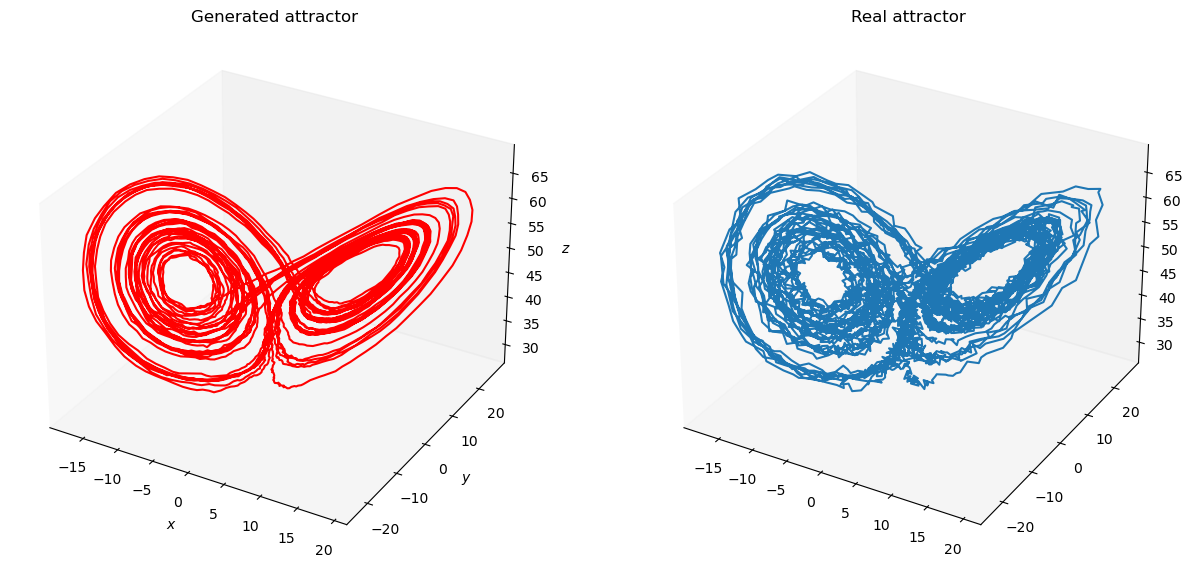

In [27]:
with bm.environment(bm.batching_mode):
    model_TIN = ESN(num_in=3, num_hidden=1148, num_out=3, Wrec_initializer=TIN_matrix, Win_initializer=bp.init.Uniform(-0.1, 0.1))
    model_TIN.reset(1)
    trainer_Ridge_TIN = bp.OfflineTrainer(model_TIN, fit_method=bp.algorithms.RidgeRegression(1e-7), dt=dt, progress_bar=True)
    _TIN = trainer_Ridge_TIN.predict(X_warmup)
    _TIN = trainer_Ridge_TIN.fit([X_train, Y_train])
    TIN_outputs = trainer_Ridge_TIN.predict(X_test)
    print('Prediction NMS: ', bp.losses.mean_squared_error(TIN_outputs, Y_ground))

def plot_lorenz(ground_truth, predictions):
  fig = plt.figure(figsize=(15, 10))
  ax = fig.add_subplot(121, projection='3d')
  ax.set_title("Generated attractor")
  ax.set_xlabel("$x$")
  ax.set_ylabel("$y$")
  ax.set_zlabel("$z$")
  ax.grid(False)
  ax.plot(predictions[:, 0], predictions[:, 1], predictions[:, 2], color = 'r')

  ax2 = fig.add_subplot(122, projection='3d')
  ax2.set_title("Real attractor")
  ax2.grid(False)
  ax2.plot(ground_truth[:, 0], ground_truth[:, 1], ground_truth[:, 2])
  plt.savefig('TIN_000_1.pdf')
  plt.show()

plot_lorenz(bm.as_numpy(Y_test).squeeze(), bm.as_numpy(TIN_outputs).squeeze())

In [28]:
# with bm.environment(bm.batching_mode):
#     model_TIN = ESN(num_in=3, num_hidden=1148, num_out=3, Wrec_initializer=scaled_E_TIN, Win_initializer=bp.init.Uniform(-0.1, 0.1))
#     model_TIN.reset(1)
#     trainer_Ridge_TIN = bp.OfflineTrainer(model_TIN, fit_method=bp.algorithms.RidgeRegression(1e-7), dt=dt, progress_bar=True)
#     _TIN = trainer_Ridge_TIN.predict(X_warmup)
#     _TIN = trainer_Ridge_TIN.fit([X_train, Y_train])
#     TIN_outputs = trainer_Ridge_TIN.predict(X_test)
#     print('Prediction NMS: ', bp.losses.mean_squared_error(TIN_outputs, Y_ground))

# def plot_lorenz(ground_truth, predictions):
#   fig = plt.figure(figsize=(15, 10))
#   ax = fig.add_subplot(121, projection='3d')
#   ax.set_title("Generated attractor")
#   ax.set_xlabel("$x$")
#   ax.set_ylabel("$y$")
#   ax.set_zlabel("$z$")
#   ax.grid(False)
#   ax.plot(predictions[:, 0], predictions[:, 1], predictions[:, 2], color = 'r')

#   ax2 = fig.add_subplot(122, projection='3d')
#   ax2.set_title("Real attractor")
#   ax2.grid(False)
#   ax2.plot(ground_truth[:, 0], ground_truth[:, 1], ground_truth[:, 2])
#   plt.savefig('TIN_001_1.pdf')
#   plt.show()

# plot_lorenz(bm.as_numpy(Y_test).squeeze(), bm.as_numpy(TIN_outputs).squeeze())

  0%|          | 0/1499 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

Prediction NMS:  0.06958538206805821


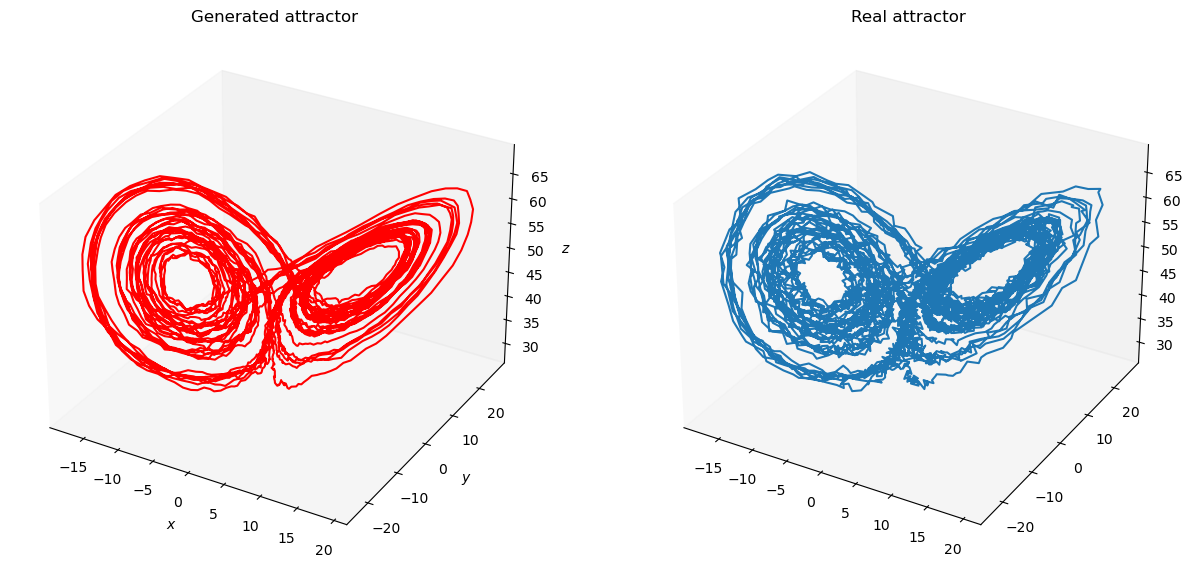

In [29]:
class ResNet(bp.DynamicalSystemNS):
    def __init__(self, num_in, num_recs, num_out):
        super(ResNet, self).__init__()
        self.r = bp.dnn.Reservoir(num_in, num_recs, rec_connectivity=0.005, comp_type='dense',
                                  leaky_rate=0.2, Win_initializer=bp.init.Uniform(-0.1, 0.1), Wrec_initializer=bp.init.Normal(scale=0.1))
        self.o = bp.layers.Dense(num_recs, num_out, mode=bm.training_mode)

    def update(self, x):
        return x >> self.r >> self.o

# model
with bm.environment(bm.batching_mode):
    model = ResNet(3, 1148, 3)


# 设定trainer之后绘图
trainer = bp.OfflineTrainer(model, fit_method=bp.algorithms.RidgeRegression(1e-7), dt=dt, progress_bar=True)
_ = trainer.predict(X_warmup)
_ = trainer.fit([X_train, Y_train])

def plot_lorenz(ground_truth, predictions):
  fig = plt.figure(figsize=(15, 10))
  ax = fig.add_subplot(121, projection='3d')
  ax.set_title("Generated attractor")
  ax.set_xlabel("$x$")
  ax.set_ylabel("$y$")
  ax.set_zlabel("$z$")
  ax.grid(False)
  ax.plot(predictions[:, 0], predictions[:, 1], predictions[:, 2], color = 'r')

  ax2 = fig.add_subplot(122, projection='3d')
  ax2.set_title("Real attractor")
  ax2.grid(False)
  ax2.plot(ground_truth[:, 0], ground_truth[:, 1], ground_truth[:, 2])
  plt.savefig('Res_001_1.pdf')
  plt.show()

outputs = trainer.predict(X_test)
print('Prediction NMS: ', bp.losses.mean_squared_error(outputs, Y_ground))
plot_lorenz(bm.as_numpy(Y_test).squeeze(), bm.as_numpy(outputs).squeeze())

  0%|          | 0/1499 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

Prediction NMS:  0.09798886481227408


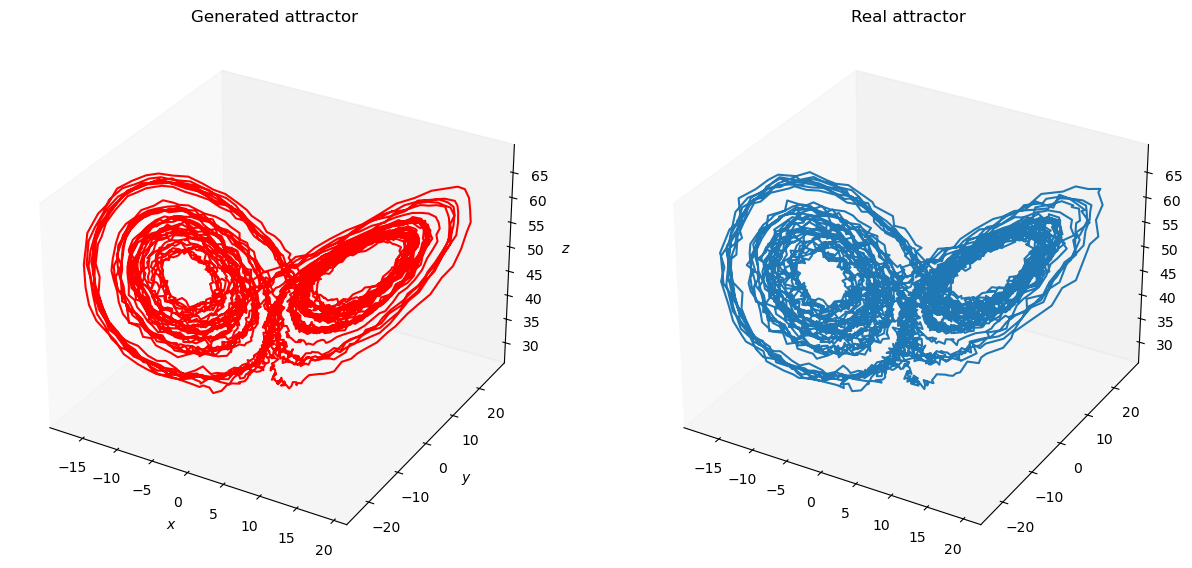

In [30]:
class GRU(bp.DynamicalSystemNS):
  def __init__(self, num_in, num_hidden, num_out):
    super(GRU, self).__init__()
    self.r = bp.layers.GRUCell(num_in, num_hidden)
    self.o = bp.layers.Dense(num_hidden, num_out, W_initializer=bp.init.Normal(),
                             mode=bm.training_mode)

  def update(self, x):
    return x >> self.r >> self.o

with bm.environment(bm.batching_mode):
    model = GRU(3, 1148, 3)


# 设定trainer之后绘图
trainer = bp.OfflineTrainer(model, fit_method=bp.algorithms.RidgeRegression(1e-7), dt=dt, progress_bar=True)
_ = trainer.predict(X_warmup)
_ = trainer.fit([X_train, Y_train])

def plot_lorenz(ground_truth, predictions):
  fig = plt.figure(figsize=(15, 10))
  ax = fig.add_subplot(121, projection='3d')
  ax.set_title("Generated attractor")
  ax.set_xlabel("$x$")
  ax.set_ylabel("$y$")
  ax.set_zlabel("$z$")
  ax.grid(False)
  ax.plot(predictions[:, 0], predictions[:, 1], predictions[:, 2], color = 'r')

  ax2 = fig.add_subplot(122, projection='3d')
  ax2.set_title("Real attractor")
  ax2.grid(False)
  ax2.plot(ground_truth[:, 0], ground_truth[:, 1], ground_truth[:, 2])
  plt.savefig('GRU_001_5.pdf')
  plt.show()

outputs = trainer.predict(X_test)
print('Prediction NMS: ', bp.losses.mean_squared_error(outputs, Y_ground))
plot_lorenz(bm.as_numpy(Y_test).squeeze(), bm.as_numpy(outputs).squeeze())

  0%|          | 0/1499 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

Prediction NMS:  0.4199706845551396


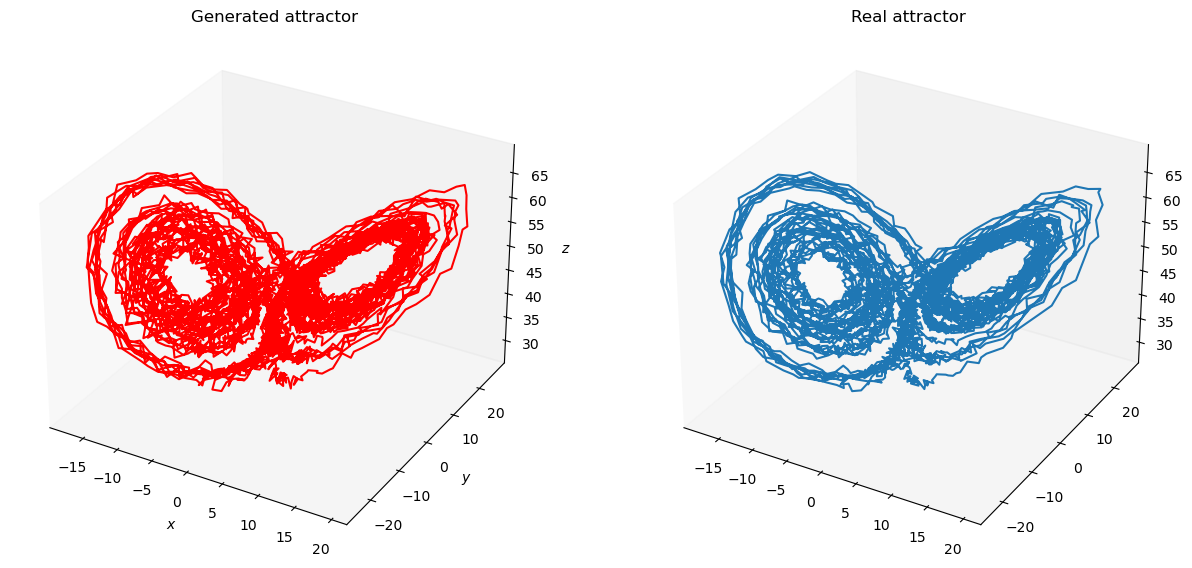

In [31]:
class RNN(bp.DynamicalSystemNS):
  def __init__(self, num_in, num_hidden, num_out):
    super(RNN, self).__init__()
    self.r = bp.layers.RNNCell(num_in, num_hidden)
    self.o = bp.layers.Dense(num_hidden, num_out, W_initializer=bp.init.Normal(),
                             mode=bm.training_mode)

  def update(self, x):
    return x >> self.r >> self.o


with bm.environment(bm.batching_mode):
    model = RNN(3, 1148, 3)

# 设定trainer之后绘图
trainer = bp.OfflineTrainer(model, fit_method=bp.algorithms.RidgeRegression(1e-7), dt=dt, progress_bar=True)
_ = trainer.predict(X_warmup)
_ = trainer.fit([X_train, Y_train])

def plot_lorenz(ground_truth, predictions):
  fig = plt.figure(figsize=(15, 10))
  ax = fig.add_subplot(121, projection='3d')
  ax.set_title("Generated attractor")
  ax.set_xlabel("$x$")
  ax.set_ylabel("$y$")
  ax.set_zlabel("$z$")
  ax.grid(False)
  ax.plot(predictions[:, 0], predictions[:, 1], predictions[:, 2], color = 'r')

  ax2 = fig.add_subplot(122, projection='3d')
  ax2.set_title("Real attractor")
  ax2.grid(False)
  ax2.plot(ground_truth[:, 0], ground_truth[:, 1], ground_truth[:, 2])
  plt.savefig('RNN_001_5.pdf')
  plt.show()

outputs = trainer.predict(X_test)
print('Prediction NMS: ', bp.losses.mean_squared_error(outputs, Y_ground))
plot_lorenz(bm.as_numpy(Y_test).squeeze(), bm.as_numpy(outputs).squeeze())

  0%|          | 0/1499 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

Prediction NMS:  0.08705341856357433


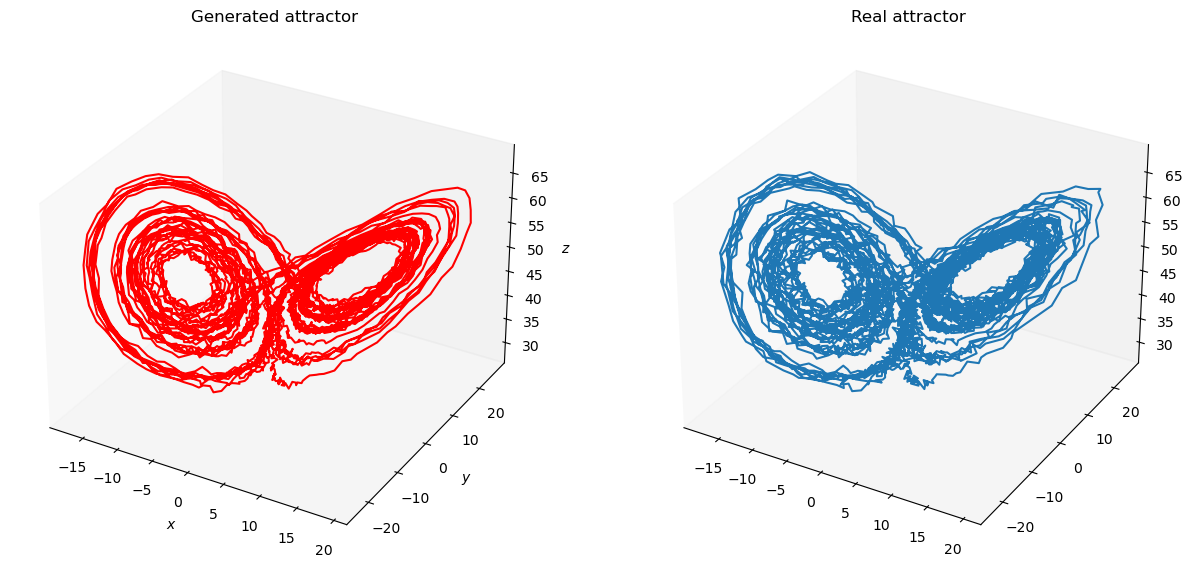

In [32]:
class LSTM(bp.DynamicalSystemNS):
  def __init__(self, num_in, num_hidden, num_out):
    super(LSTM, self).__init__()
    self.r = bp.layers.LSTMCell(num_in, num_hidden)
    self.o = bp.layers.Dense(num_hidden, num_out, W_initializer=bp.init.Normal(),
                             mode=bm.training_mode)

  def update(self, x):
    return x >> self.r >> self.o


with bm.environment(bm.batching_mode):
    model = LSTM(3, 1148, 3)

# 设定trainer之后绘图
trainer = bp.OfflineTrainer(model, fit_method=bp.algorithms.RidgeRegression(1e-7), dt=dt, progress_bar=True)
_ = trainer.predict(X_warmup)
_ = trainer.fit([X_train, Y_train])

def plot_lorenz(ground_truth, predictions):
  fig = plt.figure(figsize=(15, 10))
  ax = fig.add_subplot(121, projection='3d')
  ax.set_title("Generated attractor")
  ax.set_xlabel("$x$")
  ax.set_ylabel("$y$")
  ax.set_zlabel("$z$")
  ax.grid(False)
  ax.plot(predictions[:, 0], predictions[:, 1], predictions[:, 2], color = 'r')

  ax2 = fig.add_subplot(122, projection='3d')
  ax2.set_title("Real attractor")
  ax2.grid(False)
  ax2.plot(ground_truth[:, 0], ground_truth[:, 1], ground_truth[:, 2])
  plt.savefig('LSTM_001_5.pdf')
  plt.show()

outputs = trainer.predict(X_test)
print('Prediction NMS: ', bp.losses.mean_squared_error(outputs, Y_ground))
plot_lorenz(bm.as_numpy(Y_test).squeeze(), bm.as_numpy(outputs).squeeze())